# Cloning quasars 
## Let's look at the redshift distributions of the quasars in the Sloan Digital Sky Survey.
### The following are 2 parts:
* 1- Cloning Data from the SDSS survey
* 2- Play with the data
*  a- Rejection sampling
*  b- Inverse Transrom

In [78]:
import scipy.stats
import astropy
import numpy as np
import pylab as plt
import os

# Cloning data

In [79]:
from urllib.request import urlretrieve
filename = './dr7qso.dat'
if not os.path.exists(filename):
    urlretrieve("https://das.sdss.org/va/qsocat/dr7qso.dat", './dr7qso.dat')


[1.8246 1.8373 1.1985 ... 1.6937 1.2834 1.3542]


Text(0.5, 0, 'z')

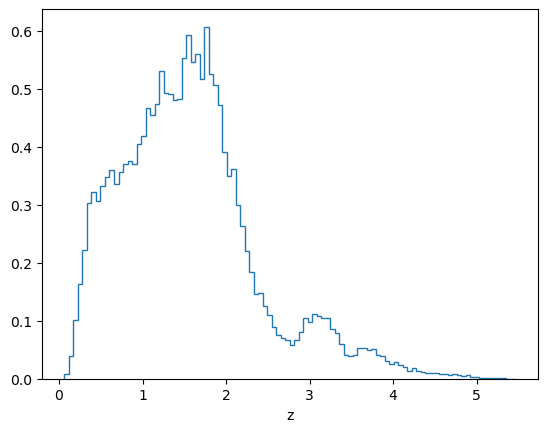

In [80]:
# There are 80 header lines, skip them. The redshift is in column 3. 
# Careful that there's another z feature, but that refers to the SDSS z filter, not the redshift
z= np.loadtxt('dr7qso.dat',skiprows=80, usecols=3)
os.remove(filename)  
print(z)
plt.hist(z,bins=100,density=True,histtype='step',lw=1);
plt.xlabel('z')

# Play with the Data
- Upsample this distribution in hopefully two ways (but at least one of them), using both rejection sampling and inverse transform.
- Check, at least visually, that the two cloned distribitions are indeed similar to the observed one (for a quantitative check, come back to this point in a few lectures)
- Think about the cosmology of quasars. How do you think they are distributed? Overplot the theorethical distribution to the measured SDSS data. Does that agree with your expectation? 

(Hint: It shouldn't. But why?) 

# Rejection sampling

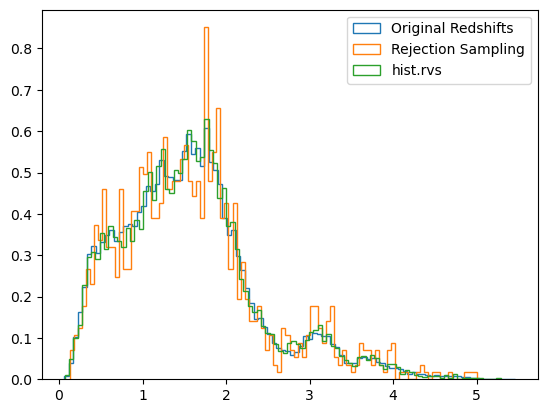

In [81]:
# Extract the data histogram values from z:
counts, bins = np.histogram(z, bins=100, density=True)
# Take the maximum:
maxi = max(counts)

hist = scipy.stats.rv_histogram((counts,bins))

N = 10000  # Increase, Decrease N and see the change.....
q = np.random.uniform(-5,10,N)
u = np.random.uniform(0,maxi,N)

pdf = hist.pdf(q)  
mask = u <= pdf

monte_carlo = q[mask]

fig , ax0 = plt.subplots()
ax0.hist(z, bins=100,histtype='step', density=True, label='Original Redshifts')
ax0.hist(monte_carlo, bins=100,histtype='step',density=True, label='Rejection Sampling')
ax0.hist(hist.rvs(size=N),bins= 100, histtype='step',density=True, label='hist.rvs')  # It represents a direct command to the inverse trasform.
ax0.legend()
plt.show()


# Results:
* **Rejection sampling** shows the process of the `hist.rvs` code. The `hist.rvs` is more accurate (Using advanced scientific stuff) but it would be used only for simple cases. In multidimentional histograms, we would need **Rejection sampling** Method.
* Increase `N` (Number of trials), the histograms become much closer to the original data.

## Remember to : 
* Revise the relationship between Monte Carlo integration and Rejection sampling

# Inverse Transform
* It creates new values depeding on the inverse of the cdf (`scipy.interpolate.interp1d`).

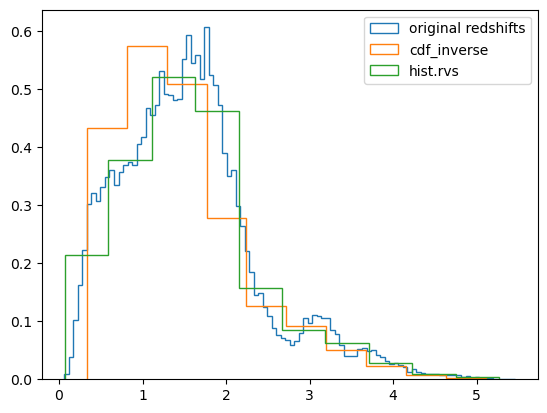

In [82]:
N = 10000  # The number of samples
b =10      # The number of bins do matter here, increase decrease and compare
counts, bins = np.histogram(z, bins= b, density=True) 

bin_mids = (bins[1:] + bins[:-1]) / 2

cdf = np.cumsum(counts)/np.sum(counts) # cdf = cumulative distribution function values

cdf_inverse = scipy.interpolate.interp1d(cdf, bin_mids) # It is the inverse function of cdf

maxh = np.random.uniform(min(cdf),max(cdf), N)  # the maximum hight
x_sample = cdf_inverse(maxh)      # find the new z values
plt.hist(z,bins=100, density= True, histtype='step', label= 'original redshifts')
plt.hist(x_sample,bins= b, density=True, histtype='step', label= 'cdf_inverse')
plt.hist(hist.rvs(size=N),bins= b, histtype='step',density=True, label='hist.rvs')  # It represents a direct command to the inverse trasform.

plt.legend();

# Important Note:
* `hist.rvs(size = N))` is a direct command that produces new values instead of going through the inverse transfrom method.

# Cosmolgical work: I am not interested in the topic. Although, it's an application.
* From cosmology, different values $\lambda$ for a flat universe depending on a research done. 
### We need to extract redshifts (**z**) values depending on the quasers data we have using `differential_comoving_volume`. 

In [83]:
astropy.cosmology.Planck18

FlatLambdaCDM(name='Planck18', H0=<Quantity 67.66 km / (Mpc s)>, Om0=0.30966, Tcmb0=<Quantity 2.7255 K>, Neff=3.046, m_nu=<Quantity [0.  , 0.  , 0.06] eV>, Ob0=0.04897)

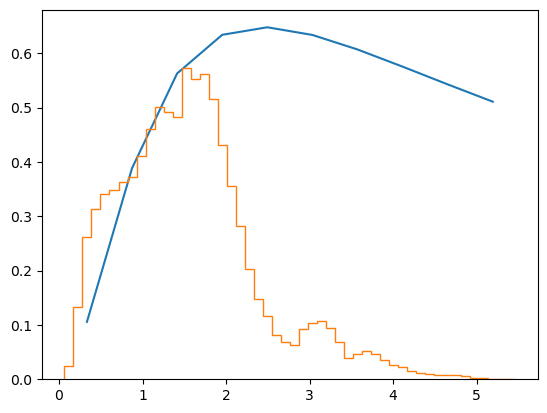

In [85]:
# z_vals = np.linspace(0,5,100)
z_vals = bin_mids
comvol = astropy.cosmology.Planck18.differential_comoving_volume(z_vals).value
plt.plot(bin_mids,comvol/6.5e10) ###   Arbitrary normalization, just matching by eye

plt.hist(z,bins=50,histtype='step',density=True,label='original data');

## Result for the cosmological parameter:

#### At high redshift values, the number of quasars get less while Plank18 study gives higher values of existing quasers. Are the telescopes getting full real image of the universe or we have to do something with Plank18? 